# Adult / Census Income Dataset: Analysis and Modelling

The task is binary classification. Given the demographic and employment attributes recorded for one
person by the 1994 US Census, predict whether their annual income was above or at or below fifty
thousand US dollars.

This notebook covers:

1. Descriptive analysis of the dataset
2. Data preparation, with every rule fitted on the training rows only
3. Training eight candidate classifiers: Logistic Regression, Decision Tree, Random Forest,
   XGBoost, SVM, Naive Bayes, AdaBoost and KNN
4. Evaluation on a validation split and then once on the official `adult.test` file, using
   accuracy, precision, recall, F1, ROC-AUC and confusion matrices
5. Calibration and the selection of decision band boundaries
6. Evaluation of the optional question routing model, reported separately

Raw data is read from `data/raw/` through `src.data`, the shared preparation module also used by the
deployed application, so the notebook and the application encode features identically. Figures are
written to `outputs/` and result tables the application reads are written to `models/`.


## 0. Setup

In [1]:
import sys
import pathlib
import json
import joblib

sys.path.append(str(pathlib.Path.cwd().parent))

from src import config
from src.data import load_raw, prepare_features, extract_target


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, RocCurveDisplay)
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from src.nlp import build_vocabulary, vectorise_many
from src.train import load_intents, training_examples, INTENT_ALPHA, INTENT_BINARY

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = config.RANDOM_STATE
OUTPUTS = config.OUTPUTS
MODELS = config.MODELS

OUTPUTS.mkdir(exist_ok=True)
MODELS.mkdir(exist_ok=True)


def save_figure(name, fig=None):
    """Write a figure to the outputs folder as a PNG."""
    target = fig if fig is not None else plt.gcf()
    target.savefig(OUTPUTS / f'{name}.png', dpi=150, bbox_inches='tight')


## 1. Load the data
The raw files use `?` for missing values and have a stray header line in `adult.test`; the test file's income labels also end with a trailing period (`>50K.`), which we strip so both files match. All of this is handled inside `src.data.load_raw`, so the notebook and the application read the files identically.


In [3]:
train, test = load_raw()

print('train shape:', train.shape)
print('test shape:', test.shape)
train.head()


train shape: (32561, 15)
test shape: (16281, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


### 1.1 How the data is used

| File | Rows | Role |
|---|---|---|
| `adult.data` | 32,561 | Split 80/20 into a training set of 26,048 rows and a validation set of 6,513 rows |
| `adult.test` | 16,281 | Never used in training or model selection. Used once, as a final held-out check |

**Training set**, 80% of `adult.data`. Every model is fitted on this data and only this data. Every
preparation rule that learns something, meaning the rare country grouping, the categorical levels and
the scaling values, is fitted here as well.

**Validation set**, 20% of `adult.data`. Used for the model comparison table, the calibration check
and the selection of the decision band boundaries. Most reported figures in this notebook come from
this split, which allows eight models to be compared and several experiments to be run without
touching the official test file.

**Official test set**, the separate `adult.test` file. Used only after every choice was final, to
re-evaluate the already trained models on data they were never fitted on, validated against or
selected using.


## 2. Descriptive Analysis (EDA)
### 2.1 Shape, data types, missing values, duplicates

In [4]:
print("DTYPES:\n", train.dtypes)
print("\nMISSING VALUES (train):\n", train.isnull().sum())
print("\nMISSING % (train):\n", (train.isnull().sum() / len(train) * 100).round(2))
print("\nDUPLICATES (train):", train.duplicated().sum())

DTYPES:
 age                int64
workclass         object
fnlwgt             int64
education         object
education-num      int64
marital-status    object
occupation        object
relationship      object
race              object
sex               object
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country    object
income            object
dtype: object

MISSING VALUES (train):
 age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64

MISSING % (train):
 age               0.00
workclass         5.64
fnlwgt            0.00
education         0.00
education-num     0.00
marital-status    0.00
occupation        5.66
relationship      0.00
race         

### 2.2 Numeric summary statistics

In [5]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
age,32561.0,38.581647,13.640433,17.0,28.0,37.0,48.0,90.0
fnlwgt,32561.0,189778.366512,105549.977697,12285.0,117827.0,178356.0,237051.0,1484705.0
education-num,32561.0,10.080679,2.572720,1.0,9.0,10.0,12.0,16.0
capital-gain,32561.0,1077.648844,7385.292085,0.0,0.0,0.0,0.0,99999.0
capital-loss,32561.0,87.303830,402.960219,0.0,0.0,0.0,0.0,4356.0
hours-per-week,32561.0,40.437456,12.347429,1.0,40.0,40.0,45.0,99.0


### 2.3 Categorical value counts

In [6]:
cat_cols = ['workclass', 'education', 'marital-status', 'occupation',
            'relationship', 'race', 'sex', 'native-country']
for col in cat_cols:
    print(f"\n{col}: {train[col].nunique()} unique values")
    print(train[col].value_counts().head(10))


workclass: 8 unique values
workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

education: 16 unique values
education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
Name: count, dtype: int64

marital-status: 7 unique values
marital-status
Married-civ-spouse       14976
Never-married            10683
Divorced                  4443
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse           23
Name: count, dtype: int64

occupation: 14 unique values
occupation
Prof-specialty       4140
Craft-repair         4099
Exec-managerial      4066
Adm-clerical         3770
Sales  

### 2.3b Redundancy between `education` and `education-num`

The dataset records education twice, once as a label and once as a number of years. If the two are a
strict one to one mapping they carry identical information, which affects both the feature set and
how any per attribute explanation should be read. The check below establishes whether that is the
case before Section 3 decides what to do with them.


In [7]:
mapping_counts = train.groupby('education')['education-num'].nunique()
print("Distinct education-num values per education category:")
print(mapping_counts.sort_values(ascending=False))

is_one_to_one = (mapping_counts == 1).all()
print(f"\neducation maps one to one onto education-num: {is_one_to_one}")


Distinct education-num values per education category:
education
10th            1
11th            1
12th            1
1st-4th         1
5th-6th         1
7th-8th         1
9th             1
Assoc-acdm      1
Assoc-voc       1
Bachelors       1
Doctorate       1
HS-grad         1
Masters         1
Preschool       1
Prof-school     1
Some-college    1
Name: education-num, dtype: int64

education maps one to one onto education-num: True


**Decision: both are retained, and the reason is stated rather than assumed.**

The mapping is strictly one to one, so the two columns carry identical information. Dropping
`education-num` would lose nothing, and dropping `education` would lose the readable label.

Both are kept for two reasons. Tree models are unaffected by the redundancy, since a split on
either column is equivalent, and removing one changes nothing about what the model can learn.
More importantly, the application asks the user for the qualification and derives the number of
years from it, so the pair is what allows the interface to ask one question rather than two and
still supply the model with what it was trained on.

The cost is visible in the explanation layer: attribution splits credit between the two columns
somewhat arbitrarily, so both appear in the per attribute breakdown with smaller individual
contributions than the underlying attribute really has. That is a reporting artefact, not a
modelling error, and it is noted wherever the breakdown is displayed.

### 2.4 Target class balance

income
<=50K    75.919044
>50K     24.080956
Name: proportion, dtype: float64


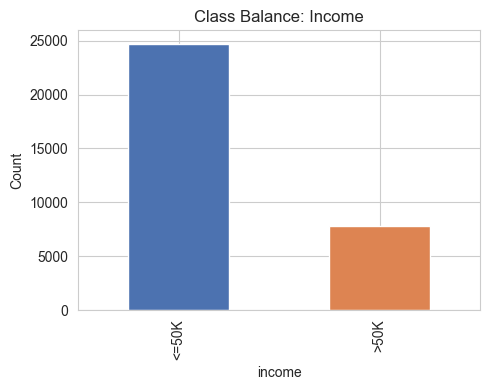

In [8]:
print(train['income'].value_counts(normalize=True) * 100)

plt.figure(figsize=(5, 4))
train['income'].value_counts().plot(kind='bar', color=['#4C72B0', '#DD8452'])
plt.title('Class Balance: Income')
plt.ylabel('Count')
plt.tight_layout()
save_figure('class_balance')
plt.show()

### 2.5 Correlation heatmap
`fnlwgt` is a census sampling weight rather than an attribute of the person, and shows almost no correlation with income.

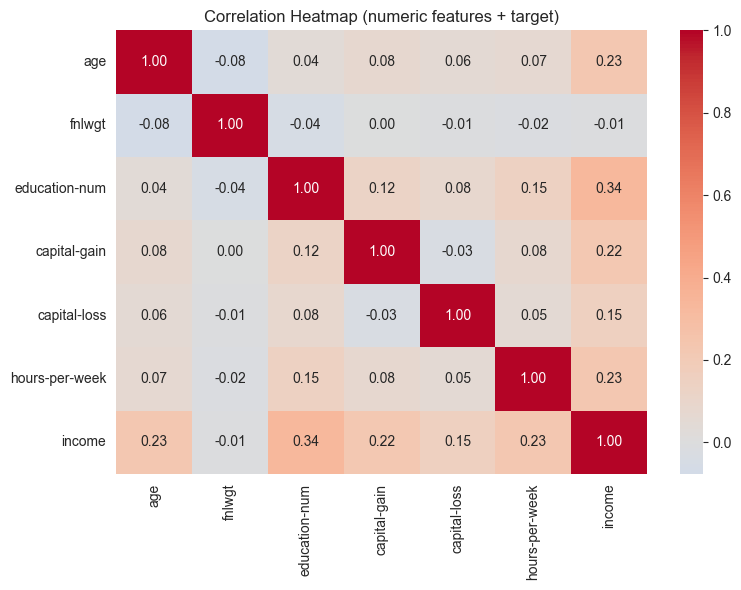

education-num     0.335154
age               0.234037
hours-per-week    0.229689
capital-gain      0.223329
capital-loss      0.150526
fnlwgt           -0.009463
Name: income, dtype: float64


In [9]:
numeric_cols = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
df_corr = train[numeric_cols].copy()
df_corr['income'] = (train['income'] == '>50K').astype(int)

plt.figure(figsize=(8, 6))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap (numeric features + target)')
plt.tight_layout()
save_figure('correlation_heatmap')
plt.show()

print(df_corr.corr()['income'].drop('income').sort_values(ascending=False))

### 2.6 Income rate by categorical feature

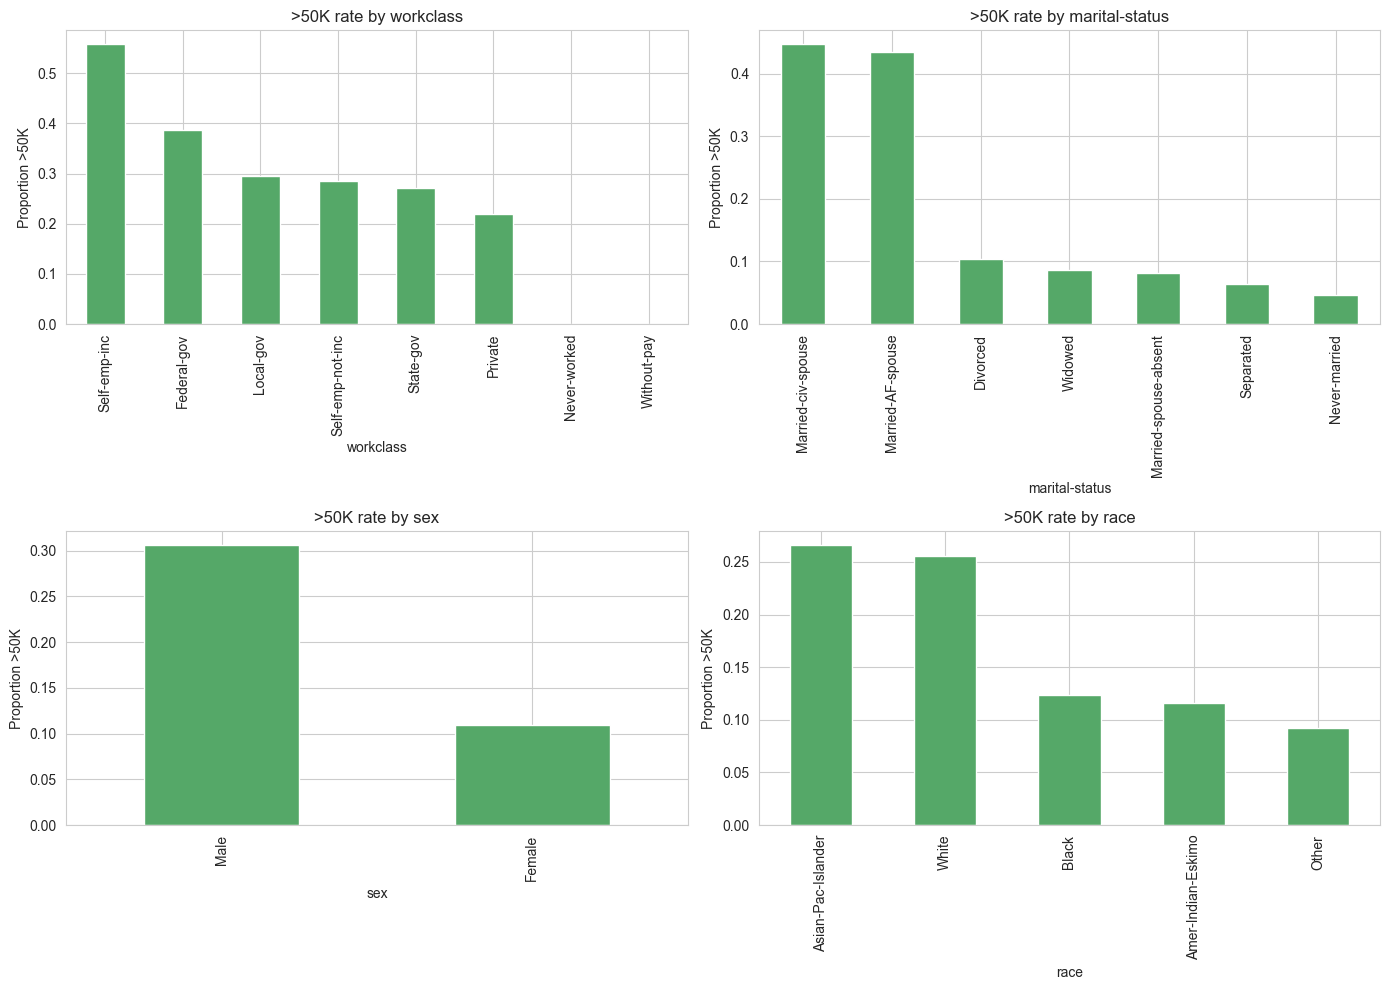

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for ax, col in zip(axes, ['workclass', 'marital-status', 'sex', 'race']):
    rate = train.groupby(col)['income'].apply(lambda x: (x == '>50K').mean()).sort_values(ascending=False)
    rate.plot(kind='bar', ax=ax, color='#55A868')
    ax.set_title(f'>50K rate by {col}')
    ax.set_ylabel('Proportion >50K')
plt.tight_layout()
save_figure('income_rate_by_category')
plt.show()

## 3. Data Preparation for ML

The raw records are split into training and validation rows before any preparation step is fitted,
because three of the steps below learn something from the data they are given.

- Fill missing categorical values in `workclass`, `occupation` and `native-country` with `'Unknown'`
  rather than dropping rows, which keeps all training rows
- Group rare `native-country` categories, those below 1% frequency measured on the training rows
  only, into `'Other'`, which avoids expanding into roughly forty one-hot columns
- One-hot encode the categorical features using the category levels observed in the training rows
  only
- Drop `fnlwgt`, a census sampling weight rather than a predictor, confirmed at near zero correlation
  in Section 2.5
- Encode the target as binary, where 1 is above the threshold and 0 is at or below it

These steps are implemented in `src.data.prepare_features`. Called without a schema it fits the
preparation on the data it is given and returns a schema recording the retained country categories,
the levels of every categorical field and the final column order. Passing that schema back reapplies
those fitted decisions unchanged.

Splitting first and fitting on the training rows alone is what keeps the validation split genuinely
unseen. The validation rows, the official `adult.test` file and a single record entered into the
application all reuse the schema fitted on training data alone.


### 3.1 Split the raw records first
Stratified split of the raw `adult.data` rows (target is imbalanced, ~76/24), done *before* any preparation step is fitted, so validation rows cannot influence the rare-country grouping or the one-hot category levels.


In [11]:
train_raw, val_raw = train_test_split(
    train, test_size=0.2, random_state=RANDOM_STATE, stratify=train['income']
)

print(f"Training rows: {train_raw.shape[0]}  Validation rows: {val_raw.shape[0]}")


Training rows: 26048  Validation rows: 6513


In [12]:
# Fit the schema (rare-country categories, one-hot levels) on the TRAINING rows only,
# then reapply that already-fitted schema, unchanged, to validation and the official test set.
X_train, schema = prepare_features(train_raw)
X_val, _ = prepare_features(val_raw, schema)
X_test_final, _ = prepare_features(test, schema)

y_train = extract_target(train_raw)
y_val = extract_target(val_raw)
y_test_final = extract_target(test)

feature_columns = schema['feature_columns']
country_categories = schema['country_categories']

print("Feature count:", X_train.shape[1])
print("Train rows:", X_train.shape[0],
      " Validation rows:", X_val.shape[0],
      " Held-out test rows:", X_test_final.shape[0])
print("Retained native-country categories (from training rows only):", len(country_categories))


Feature count: 61
Train rows: 26048  Validation rows: 6513  Held-out test rows: 16281
Retained native-country categories (from training rows only): 3


### 3.2 Scaling
The train/validation split already happened on the raw rows in Section 3.1. All that's left here is scaling, fitted on the training features only and applied unchanged to validation and the official test set.


In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_final_scaled = scaler.transform(X_test_final)

print(f"Train size: {X_train.shape[0]}, Validation size: {X_val.shape[0]}, Held-out test size: {X_test_final.shape[0]}")
print(f"Train class balance:\n{y_train.value_counts(normalize=True)}")


Train size: 26048, Validation size: 6513, Held-out test size: 16281
Train class balance:
income
0    0.759175
1    0.240825
Name: proportion, dtype: float64


**Why scale at all when the selected model is a tree ensemble?**

Scaling is not required for XGBoost, Random Forest, Decision Tree or AdaBoost: a tree splits on
an ordering, and rescaling a column does not change the ordering. It is required, or strongly
beneficial, for Logistic Regression, SVM with an RBF kernel and KNN, all of which measure
distances or fit coefficients where the units matter.

A single scaled matrix is used for all eight models so that the comparison in Section 5 is like
for like: every algorithm sees the same inputs, and any difference in performance is a property
of the algorithm rather than of the preprocessing it happened to receive. Giving each family its
own pipeline would be more precise in principle, but it would mean the comparison table no longer
isolates the algorithm as the only thing that varies.

The scaler is retained in the deployed pipeline for the same reason: the saved model was fitted on
scaled features, so inference must scale identically. It is a parity requirement, not a technical
need of the tree ensemble.

The RBF SVM is fitted on a stratified subsample of 8,000 training rows rather than all 26,048, because its training cost grows faster than linearly with the number of rows. Every other candidate sees the full training split. Its validation and test figures are therefore a floor rather than a like-for-like result, and it is reported with that qualification rather than presented as a fair loss.

## 4. Model Training

In [14]:
SVM_SUBSAMPLE_SIZE = 8000  # RBF SVM scales poorly with rows; subsample for speed

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=10,
                                             random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.1,
                              eval_metric='logloss', random_state=RANDOM_STATE),
    'SVM (RBF)': SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
    'Naive Bayes': GaussianNB(),
    'AdaBoost': AdaBoostClassifier(n_estimators=200, random_state=RANDOM_STATE),
    'KNN (k=15)': KNeighborsClassifier(n_neighbors=15, n_jobs=-1),
}

## 5. Evaluation
### 5.1 Train each model, evaluate on the validation split


Logistic Regression
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.91      4945
        >50K       0.74      0.62      0.67      1568

    accuracy                           0.86      6513
   macro avg       0.81      0.77      0.79      6513
weighted avg       0.85      0.86      0.85      6513


Decision Tree
              precision    recall  f1-score   support

       <=50K       0.87      0.95      0.91      4945
        >50K       0.79      0.56      0.65      1568

    accuracy                           0.86      6513
   macro avg       0.83      0.76      0.78      6513
weighted avg       0.85      0.86      0.85      6513



c:\Users\Ausbeth\Documents\Important Docs\Southampton Solent\MSc Applied AI & Data Science\COM727-Chatbot-Assessment\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(



Random Forest
              precision    recall  f1-score   support

       <=50K       0.87      0.96      0.91      4945
        >50K       0.81      0.56      0.66      1568

    accuracy                           0.86      6513
   macro avg       0.84      0.76      0.79      6513
weighted avg       0.86      0.86      0.85      6513


XGBoost
              precision    recall  f1-score   support

       <=50K       0.90      0.94      0.92      4945
        >50K       0.78      0.67      0.72      1568

    accuracy                           0.87      6513
   macro avg       0.84      0.80      0.82      6513
weighted avg       0.87      0.87      0.87      6513


SVM (RBF)
              precision    recall  f1-score   support

       <=50K       0.87      0.93      0.90      4945
        >50K       0.74      0.58      0.65      1568

    accuracy                           0.85      6513
   macro avg       0.80      0.76      0.78      6513
weighted avg       0.84      0.85      

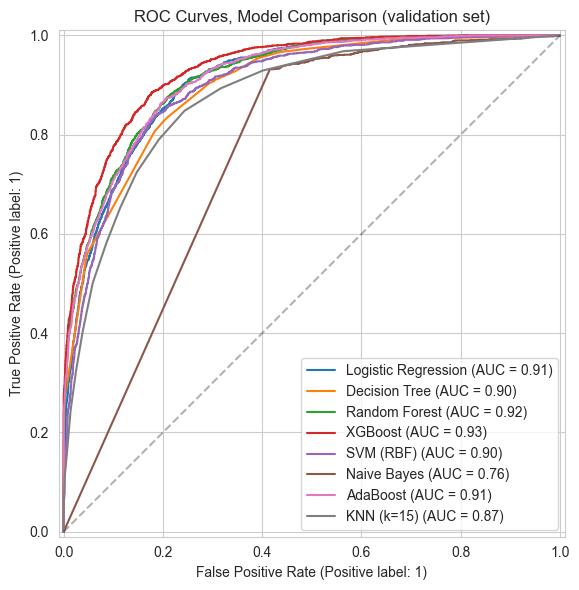

In [15]:
results = []
fig, ax = plt.subplots(figsize=(7, 6))

y_preds = {}  # cache predictions for the confusion-matrix cell below

for name, model in models.items():
    if name == 'SVM (RBF)' and X_train_scaled.shape[0] > SVM_SUBSAMPLE_SIZE:
        X_fit, _, y_fit, _ = train_test_split(
            X_train_scaled, y_train, train_size=SVM_SUBSAMPLE_SIZE,
            random_state=RANDOM_STATE, stratify=y_train
        )
    else:
        X_fit, y_fit = X_train_scaled, y_train
    model.fit(X_fit, y_fit)
    y_pred = model.predict(X_val_scaled)
    y_proba = model.predict_proba(X_val_scaled)[:, 1]
    y_preds[name] = y_pred

    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred)
    rec = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_proba)

    results.append({'Model': name, 'Accuracy': acc, 'Precision': prec,
                     'Recall': rec, 'F1': f1, 'ROC_AUC': auc})

    print(f"\n{'=' * 50}\n{name}\n{'=' * 50}")
    print(classification_report(y_val, y_pred, target_names=['<=50K', '>50K']))

    # Explicitly plot onto the ROC figure's own axes (not pyplot's "current
    # figure", which changes as soon as any other figure is created).
    RocCurveDisplay.from_predictions(y_val, y_proba, name=name, ax=ax)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_title('ROC Curves, Model Comparison (validation set)')
fig.tight_layout()
save_figure('roc_curves', fig)
plt.show()

### 5.1b Confusion matrices

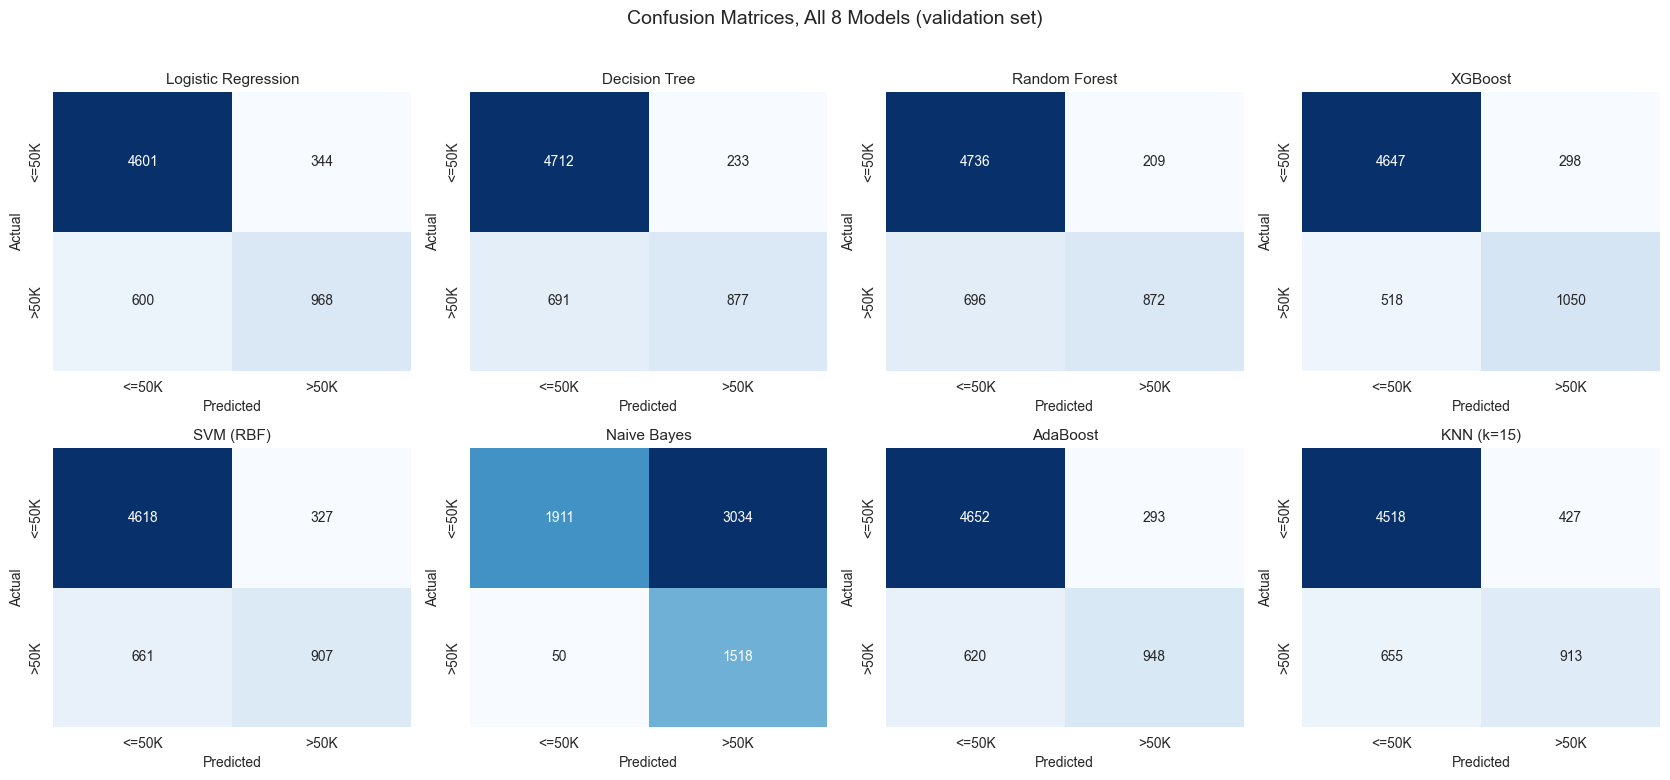

              Model  True Negatives  False Positives  False Negatives  True Positives  True Positive Rate  True Negative Rate  False Positive Rate  False Negative Rate
      Random Forest            4736              209              696             872            0.556122            0.957735             0.042265             0.443878
      Decision Tree            4712              233              691             877            0.559311            0.952882             0.047118             0.440689
           AdaBoost            4652              293              620             948            0.604592            0.940748             0.059252             0.395408
            XGBoost            4647              298              518            1050            0.669643            0.939737             0.060263             0.330357
          SVM (RBF)            4618              327              661             907            0.578444            0.933873             0.066127             0

In [16]:
model_order = list(models.keys())
n_models = len(model_order)
n_cols = 4
n_rows = -(-n_models // n_cols)  # ceil division

fig_cm, axes_cm = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 3.8 * n_rows))
axes_cm = axes_cm.flatten()

cm_summary = []

for i, name in enumerate(model_order):
    y_pred = y_preds[name]
    cm = confusion_matrix(y_val, y_pred)
    tn, fp, fn, tp = cm.ravel()
    cm_summary.append({
        'Model': name, 'True Negatives': tn, 'False Positives': fp,
        'False Negatives': fn, 'True Positives': tp,
        'True Positive Rate': tp / (tp + fn),   #  Recall / Sensitivity
        'True Negative Rate': tn / (tn + fp),   #  Specificity
        'False Positive Rate': fp / (fp + tn),
        'False Negative Rate': fn / (fn + tp),
    })

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'],
                ax=axes_cm[i], cbar=False)
    axes_cm[i].set_title(name, fontsize=11)
    axes_cm[i].set_ylabel('Actual')
    axes_cm[i].set_xlabel('Predicted')

# Hide any unused subplot slots (grid may have more cells than models)
for j in range(n_models, len(axes_cm)):
    axes_cm[j].axis('off')

fig_cm.suptitle('Confusion Matrices, All 8 Models (validation set)', fontsize=14, y=1.02)
fig_cm.tight_layout()
save_figure('confusion_matrices', fig_cm)
plt.show()

cm_summary_df = pd.DataFrame(cm_summary).sort_values('False Positive Rate')
cm_summary_df.to_csv(OUTPUTS / 'confusion_matrix_summary.csv', index=False)
print(cm_summary_df.to_string(index=False))

### 5.2 Compare models side by side

              Model  Accuracy  Precision   Recall       F1  ROC_AUC
            XGBoost  0.874712   0.778932 0.669643 0.720165 0.931426
           AdaBoost  0.859819   0.763900 0.604592 0.674973 0.914321
Logistic Regression  0.855059   0.737805 0.617347 0.672222 0.910102
      Random Forest  0.861047   0.806660 0.556122 0.658362 0.915849
      Decision Tree  0.858130   0.790090 0.559311 0.654966 0.898136
          SVM (RBF)  0.848303   0.735008 0.578444 0.647395 0.898136
         KNN (k=15)  0.833871   0.681343 0.582270 0.627923 0.874665
        Naive Bayes  0.526485   0.333480 0.968112 0.496078 0.763530


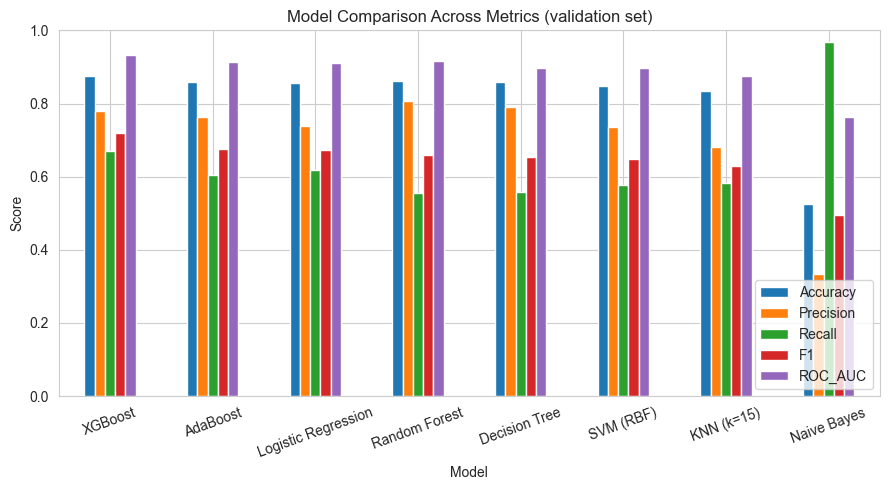

In [17]:
results_df = pd.DataFrame(results).sort_values('F1', ascending=False)
print(results_df.to_string(index=False))
results_df.to_csv(MODELS / 'model_comparison.csv', index=False)

results_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC']].plot(
    kind='bar', figsize=(9, 5))
plt.title('Model Comparison Across Metrics (validation set)')
plt.ylabel('Score')
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
save_figure('model_comparison')
plt.show()

### 5.2b Training against validation

A model that has memorised its training rows scores far higher on them than on rows it has not seen.
Comparing the two directly is the first check on overfitting, and it is done here for all eight
models rather than only for the one that is eventually selected. Section 5.5 extends the comparison
to the official test file once every model has been evaluated on it.


In [18]:
train_rows = []
for name, model in models.items():
    y_train_pred = model.predict(X_train_scaled)
    y_train_proba = model.predict_proba(X_train_scaled)[:, 1]
    train_rows.append({
        'Model': name,
        'Accuracy_train': accuracy_score(y_train, y_train_pred),
        'F1_train': f1_score(y_train, y_train_pred),
        'ROC_AUC_train': roc_auc_score(y_train, y_train_proba),
    })

train_df = pd.DataFrame(train_rows)

train_vs_val = train_df.merge(
    results_df[['Model', 'Accuracy', 'F1', 'ROC_AUC']].rename(
        columns={'Accuracy': 'Accuracy_val', 'F1': 'F1_val', 'ROC_AUC': 'ROC_AUC_val'}),
    on='Model')
train_vs_val['Train_minus_Val'] = (train_vs_val['Accuracy_train']
                                   - train_vs_val['Accuracy_val'])
train_vs_val = train_vs_val.sort_values('Accuracy_val', ascending=False)

print(train_vs_val[['Model', 'Accuracy_train', 'Accuracy_val', 'F1_train', 'F1_val',
                    'Train_minus_Val']].to_string(
                    index=False, float_format=lambda v: f"{v:.4f}"))


              Model  Accuracy_train  Accuracy_val  F1_train  F1_val  Train_minus_Val
            XGBoost          0.8903        0.8747    0.7536  0.7202           0.0156
      Random Forest          0.8658        0.8610    0.6699  0.6584           0.0048
           AdaBoost          0.8558        0.8598    0.6615  0.6750          -0.0041
      Decision Tree          0.8552        0.8581    0.6452  0.6550          -0.0029
Logistic Regression          0.8507        0.8551    0.6579  0.6722          -0.0043
          SVM (RBF)          0.8530        0.8483    0.6572  0.6474           0.0047
         KNN (k=15)          0.8512        0.8339    0.6623  0.6279           0.0174
        Naive Bayes          0.5265        0.5265    0.4949  0.4961          -0.0000


### 5.3 Feature importance (Random Forest)

marital-status_Married-civ-spouse    0.183817
capital-gain                         0.174987
education-num                        0.121488
age                                  0.071936
marital-status_Never-married         0.063983
hours-per-week                       0.048697
capital-loss                         0.038582
relationship_Not-in-family           0.033253
occupation_Exec-managerial           0.032812
sex_Male                             0.031082
occupation_Prof-specialty            0.023276
education_Bachelors                  0.023199
relationship_Own-child               0.022700
relationship_Unmarried               0.015874
education_Masters                    0.014402
dtype: float64


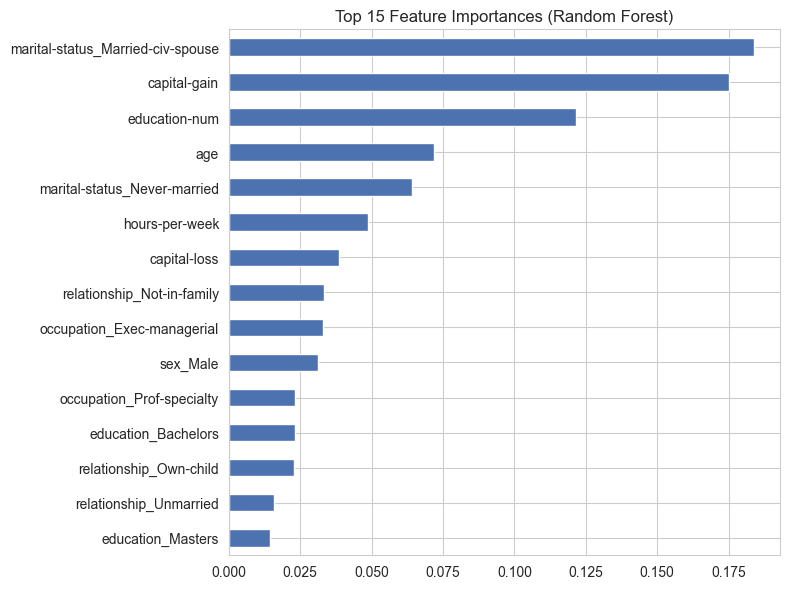

In [19]:
rf = models['Random Forest']
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(importances.head(15))

plt.figure(figsize=(8, 6))
importances.head(15).plot(kind='barh', color='#4C72B0')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
save_figure('feature_importance_rf')
plt.show()


### 5.4 First check on the held-out `adult.test` file

Everything to this point was evaluated on the validation split carved out of `adult.data`. The single
best performing model by validation F1 is now evaluated on the official `adult.test` file, which it
has never been fitted on, validated against or selected using. Section 5.5 extends the same check to
all eight models.

The test figures here and in Section 5.5 are reported, not used. The band boundaries chosen in
Section 6 are selected from validation predictions alone, so no test result influences any remaining
choice in this notebook.

Best model by validation F1: XGBoost

Held-out test performance (XGBoost):


              precision    recall  f1-score   support

       <=50K       0.90      0.94      0.92     12435
        >50K       0.77      0.66      0.71      3846

    accuracy                           0.87     16281
   macro avg       0.83      0.80      0.81     16281
weighted avg       0.87      0.87      0.87     16281

ROC-AUC: 0.92730643443671


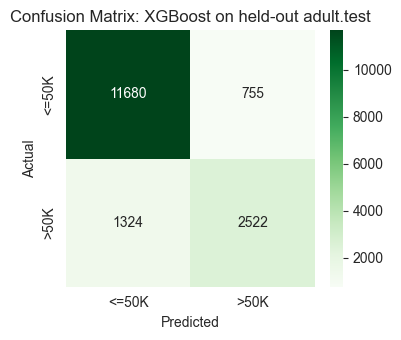

In [20]:
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
print(f"Best model by validation F1: {best_model_name}")

y_test_pred = best_model.predict(X_test_final_scaled)
y_test_proba = best_model.predict_proba(X_test_final_scaled)[:, 1]

print(f"\nHeld-out test performance ({best_model_name}):")
print(classification_report(y_test_final, y_test_pred, target_names=['<=50K', '>50K']))
print("ROC-AUC:", roc_auc_score(y_test_final, y_test_proba))

cm = confusion_matrix(y_test_final, y_test_pred)
plt.figure(figsize=(4, 3.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
plt.title(f'Confusion Matrix: {best_model_name} on held-out adult.test')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
save_figure('confusion_matrix_heldout_best')
plt.show()

**Reading the confusion matrix, and why recall is the number that matters here.**

On the official test file the model finds 2,522 of the 3,846 people who genuinely are in the upper
bracket and misses 1,324 of them. It also flags 755 people as upper bracket who are not. That is
recall of 65.6% and precision of 77.0%, against an overall accuracy of 87.2%.

Accuracy flatters the model because the classes are not balanced. Only 24.1% of records are in the
upper bracket, so a model that predicted the lower bracket for everybody would score 75.9% without
learning anything at all. The 87.2% figure is a real improvement on that, but a much smaller one
than it first appears.

**Why recall is lower than precision.** Three reasons compound. The upper bracket is the minority
class, so the model sees roughly one upper-bracket example for every three lower-bracket ones and
has less to learn from. The default decision threshold of 0.5 sits where errors are cheapest
overall, which on an imbalanced problem favours the majority class. And the two groups genuinely
overlap in this data: many people with identical recorded attributes fall on opposite sides of the
threshold, because the thirteen census attributes do not contain everything that determines income.
The referral band in Section 6 is the direct response to that overlap.

**Why it matters.** A false negative and a false positive are not equivalent in a screening
context. Missing about one in three qualifying people would, in any real application, mean
systematically under-serving them. This is also where the fairness finding bites: the miss rate is
not evenly distributed, and among people who genuinely are in the upper bracket the model finds
66.5% of the men and 60.3% of the women.

These conclusions are kept proportionate to what this is: a 1994 dataset used for an educational
prototype, not a deployed system.

### 5.5 All eight models on the official held-out test file

Section 5.4 evaluated only the best model. Every model, already fitted on the training rows alone, is
now also evaluated on the official test file, so the validation comparison in Section 5.2 can be set
directly against genuinely held-out performance.

The second table extends Section 5.2b to all three splits, giving the training against official test
gap for each algorithm.


In [21]:
results_test = []
for name, model in models.items():
    y_test_pred_i = model.predict(X_test_final_scaled)
    y_test_proba_i = model.predict_proba(X_test_final_scaled)[:, 1]
    results_test.append({
        'Model': name,
        'Accuracy_test': accuracy_score(y_test_final, y_test_pred_i),
        'Precision_test': precision_score(y_test_final, y_test_pred_i),
        'Recall_test': recall_score(y_test_final, y_test_pred_i),
        'F1_test': f1_score(y_test_final, y_test_pred_i),
        'ROC_AUC_test': roc_auc_score(y_test_final, y_test_proba_i),
    })

results_test_df = pd.DataFrame(results_test)

val_vs_test = results_df[['Model', 'Accuracy', 'F1', 'ROC_AUC']].rename(
    columns={'Accuracy': 'Accuracy_val', 'F1': 'F1_val', 'ROC_AUC': 'ROC_AUC_val'}
).merge(results_test_df[['Model', 'Accuracy_test', 'F1_test', 'ROC_AUC_test']], on='Model')
val_vs_test = val_vs_test.sort_values('Accuracy_test', ascending=False)
print(val_vs_test.to_string(index=False))
val_vs_test.to_csv(MODELS / 'val_vs_test_all_models.csv', index=False)

# All three splits side by side, with the gap that matters for the overfitting check.
all_splits = (train_df.merge(val_vs_test, on='Model')
              .assign(Train_minus_Test=lambda d: d['Accuracy_train'] - d['Accuracy_test'])
              .sort_values('Accuracy_test', ascending=False))

print()
print(all_splits[['Model', 'Accuracy_train', 'Accuracy_val', 'Accuracy_test',
                  'Train_minus_Test']].to_string(
                  index=False, float_format=lambda v: f"{v:.4f}"))

all_splits.to_csv(MODELS / 'train_val_test_all_models.csv', index=False)


              Model  Accuracy_val   F1_val  ROC_AUC_val  Accuracy_test  F1_test  ROC_AUC_test
            XGBoost      0.874712 0.720165     0.931426       0.872305 0.708129      0.927306
      Random Forest      0.861047 0.658362     0.915849       0.858854 0.646026      0.911715
           AdaBoost      0.859819 0.674973     0.914321       0.857564 0.659821      0.911275
      Decision Tree      0.858130 0.654966     0.898136       0.855291 0.638095      0.895119
Logistic Regression      0.855059 0.672222     0.910102       0.852589 0.656160      0.903833
          SVM (RBF)      0.848303 0.647395     0.898136       0.846815 0.633127      0.887357
         KNN (k=15)      0.833871 0.627923     0.874665       0.834715 0.618135      0.869427
        Naive Bayes      0.526485 0.496078     0.763530       0.522388 0.485714      0.751018

              Model  Accuracy_train  Accuracy_val  Accuracy_test  Train_minus_Test
            XGBoost          0.8903        0.8747         0.8723      

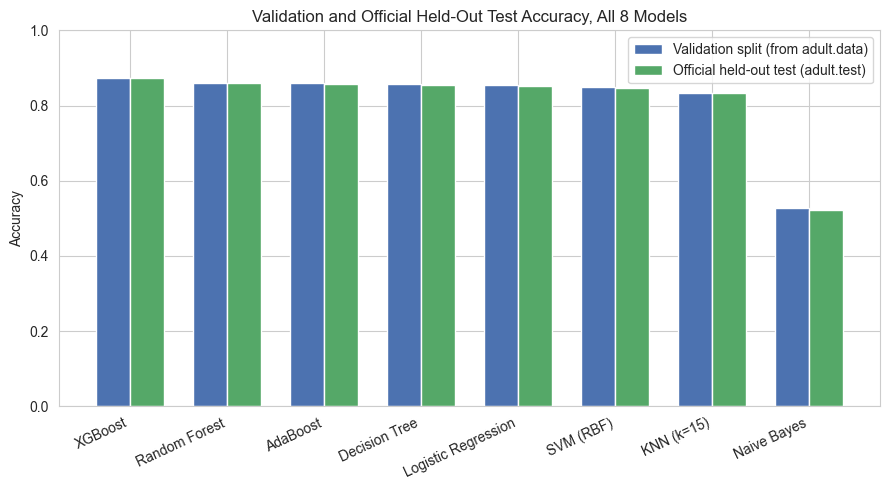


Mean absolute difference between validation and test accuracy: 0.0023


In [22]:
fig, ax = plt.subplots(figsize=(9, 5))
x_pos = np.arange(len(val_vs_test))
width = 0.35
ax.bar(x_pos - width/2, val_vs_test['Accuracy_val'], width, label='Validation split (from adult.data)', color='#4C72B0')
ax.bar(x_pos + width/2, val_vs_test['Accuracy_test'], width, label='Official held-out test (adult.test)', color='#55A868')
ax.set_xticks(x_pos)
ax.set_xticklabels(val_vs_test['Model'], rotation=25, ha='right')
ax.set_ylabel('Accuracy')
ax.set_title('Validation and Official Held-Out Test Accuracy, All 8 Models')
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
save_figure('val_vs_test_accuracy')
plt.show()

print(f"\nMean absolute difference between validation and test accuracy: "
      f"{(val_vs_test['Accuracy_val'] - val_vs_test['Accuracy_test']).abs().mean():.4f}")

Differences between validation and official test accuracy are small and consistent across the eight
models, typically well under one percentage point. That indicates the validation split was a
reliable stand-in for the official test file, so the model comparison and the band selection that
rely on it are trustworthy estimates of held-out performance rather than artefacts of one favourable
split.


## 6. Decision Bands and Calibration

The deployed application does not return a bare yes or no. It maps the predicted probability into
three bands: confidently below the threshold, confidently above it, and an uncertain middle band
where the case is escalated to a human assessor rather than decided automatically. This is the
accept, refer, decline pattern used in credit and lending screening.

Two questions have to be answered with evidence before those bands can be set.

**Are the predicted probabilities meaningful?** The bands assume that a prediction of 0.7 corresponds
to roughly a seventy percent chance of the record falling in the upper bracket. That assumption holds
well for logistic regression, which optimises the likelihood directly. It holds less reliably for
boosted ensembles, whose outputs are often pushed towards the extremes. Section 6.1 measures it.

**Where should the band boundaries go?** Widening the referral band sends more cases to a human and
raises accuracy on the automated remainder. Section 6.2 quantifies that trade-off so the chosen
boundaries can be justified with numbers rather than asserted.

In [23]:
val_proba = models['XGBoost'].predict_proba(X_val_scaled)[:, 1]
y_val_array = y_val.to_numpy()

print(f"Validation records: {len(val_proba)}")
print(f"Predicted probability range: {val_proba.min():.4f} to {val_proba.max():.4f}")
print(f"Mean predicted: {val_proba.mean():.4f}   Actual upper-bracket rate: {y_val_array.mean():.4f}")

Validation records: 6513
Predicted probability range: 0.0000 to 0.9999
Mean predicted: 0.2427   Actual upper-bracket rate: 0.2407


### 6.1 Are the probabilities calibrated?

Sort the validation predictions into ten equal-width bins. In each bin, compare the mean predicted
probability against the proportion of records that actually fall in the upper bracket. A well
calibrated model traces the diagonal.

Two summary figures accompany the curve. The **Brier score** is the mean squared difference between
predicted probability and outcome, so lower is better and 0.25 is what always predicting 0.5 would
score. The **expected calibration error** is the average gap between predicted and observed, weighted
by how many records fall in each bin.

In [24]:
n_bins = 10
bin_edges = np.linspace(0, 1, n_bins + 1)
bin_index = np.clip(np.digitize(val_proba, bin_edges[1:-1]), 0, n_bins - 1)

calibration = pd.DataFrame({'bin': bin_index, 'predicted': val_proba, 'actual': y_val_array})
calibration = calibration.groupby('bin').agg(
    count=('actual', 'size'),
    mean_predicted=('predicted', 'mean'),
    observed_rate=('actual', 'mean'),
).reset_index()
calibration['gap'] = calibration['observed_rate'] - calibration['mean_predicted']

brier = float(np.mean((val_proba - y_val_array) ** 2))
ece = float(np.average(calibration['gap'].abs(), weights=calibration['count']))

print(calibration.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print(f"\nBrier score: {brier:.4f}   (0 = perfect, 0.25 = always predicting 0.5)")
print(f"Expected calibration error: {ece:.4f}   (mean gap, weighted by bin size)")

 bin  count  mean_predicted  observed_rate     gap
   0   3520          0.0197         0.0213  0.0016
   1    557          0.1477         0.1418 -0.0059
   2    420          0.2502         0.2310 -0.0192
   3    330          0.3499         0.3394 -0.0105
   4    338          0.4471         0.4586  0.0115
   5    237          0.5462         0.5527  0.0066
   6    254          0.6510         0.6063 -0.0447
   7    262          0.7461         0.7481  0.0020
   8    140          0.8425         0.8571  0.0146
   9    455          0.9871         0.9868 -0.0003

Brier score: 0.0863   (0 = perfect, 0.25 = always predicting 0.5)
Expected calibration error: 0.0061   (mean gap, weighted by bin size)


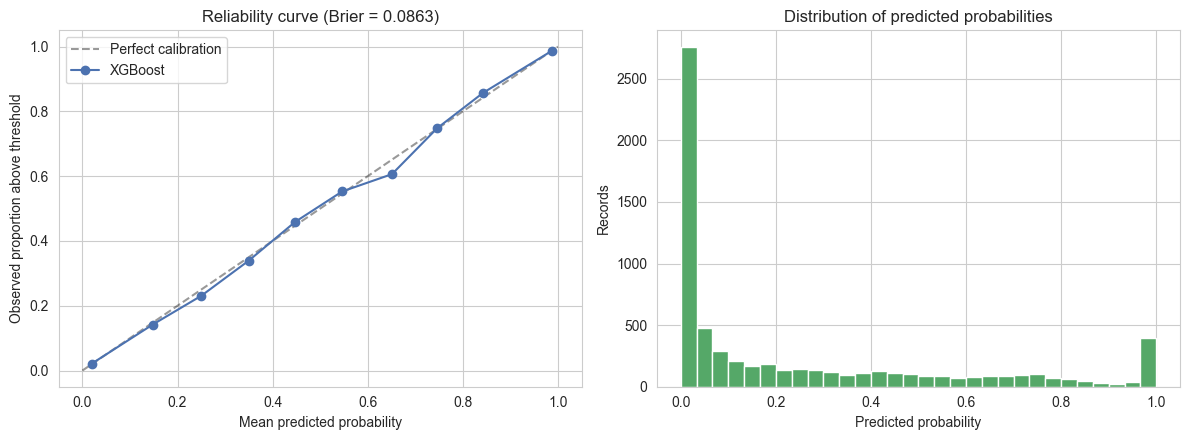

In [25]:
fig_cal, (ax_rel, ax_hist) = plt.subplots(1, 2, figsize=(12, 4.5))

ax_rel.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Perfect calibration')
ax_rel.plot(calibration['mean_predicted'], calibration['observed_rate'],
            'o-', color='#4C72B0', label='XGBoost')
ax_rel.set_xlabel('Mean predicted probability')
ax_rel.set_ylabel('Observed proportion above threshold')
ax_rel.set_title(f'Reliability curve (Brier = {brier:.4f})')
ax_rel.legend()

ax_hist.hist(val_proba, bins=30, color='#55A868')
ax_hist.set_xlabel('Predicted probability')
ax_hist.set_ylabel('Records')
ax_hist.set_title('Distribution of predicted probabilities')

fig_cal.tight_layout()
save_figure('calibration_validation', fig_cal)
plt.show()

### 6.2 Choosing the referral band

For every candidate pair of boundaries, split the validation set into cases that fall inside the band
and cases that fall outside it. Cases outside are decided automatically at the usual 0.5 cut; cases
inside would go to a human. Two figures follow: the proportion referred, and the accuracy achieved on
the automated remainder.

The comparison point is the accuracy of a single 0.5 threshold with no referral band at all, which is
what the model comparison table in Section 5.2 reports.

In [26]:
lower_candidates = np.round(np.arange(0.10, 0.50, 0.05), 2)
upper_candidates = np.round(np.arange(0.55, 0.95, 0.05), 2)

rows = []
for low in lower_candidates:
    for high in upper_candidates:
        referred = (val_proba >= low) & (val_proba <= high)
        automated = ~referred
        if automated.sum() == 0:
            continue
        auto_correct = (val_proba[automated] >= 0.5).astype(int) == y_val_array[automated]
        ref_correct = (val_proba[referred] >= 0.5).astype(int) == y_val_array[referred]
        rows.append({
            'lower': low,
            'upper': high,
            'referral_rate': referred.mean(),
            'automated_accuracy': auto_correct.mean(),
            'referred_accuracy': ref_correct.mean() if referred.sum() else np.nan,
        })

bands = pd.DataFrame(rows)
baseline = float(((val_proba >= 0.5).astype(int) == y_val_array).mean())
bands['accuracy_gain'] = bands['automated_accuracy'] - baseline

print(f"Accuracy with no referral band (single 0.5 threshold): {baseline:.4f}\n")
print(bands.sort_values('automated_accuracy', ascending=False).head(10).to_string(
    index=False, float_format=lambda v: f"{v:.4f}"))

Accuracy with no referral band (single 0.5 threshold): 0.8747

 lower  upper  referral_rate  automated_accuracy  referred_accuracy  accuracy_gain
0.1000 0.9000         0.3897              0.9796             0.7104         0.1049
0.1000 0.8500         0.3803              0.9779             0.7065         0.1032
0.1000 0.8000         0.3682              0.9755             0.7018         0.1007
0.1500 0.9000         0.3435              0.9724             0.6880         0.0977
0.1500 0.8500         0.3341              0.9709             0.6829         0.0962
0.1000 0.7500         0.3501              0.9705             0.6969         0.0958
0.1500 0.8000         0.3220              0.9688             0.6767         0.0940
0.2000 0.9000         0.3042              0.9647             0.6689         0.0900
0.1500 0.7500         0.3039              0.9643             0.6695         0.0896
0.2000 0.8500         0.2948              0.9634             0.6625         0.0887


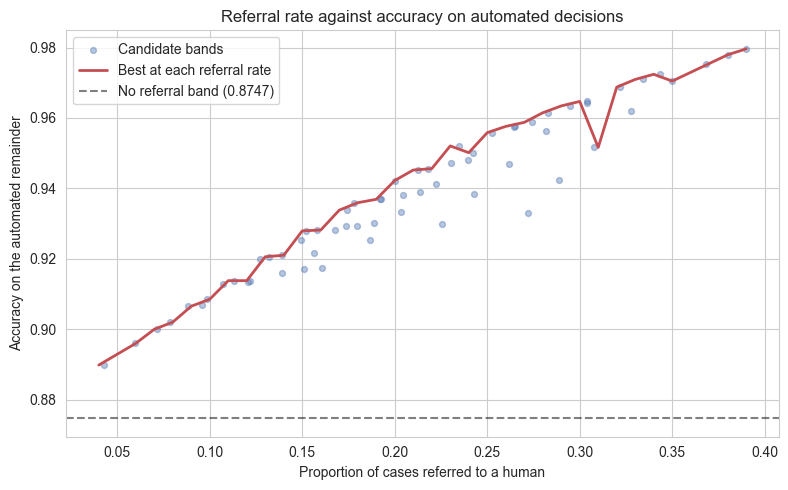

In [27]:
frontier = bands.sort_values('referral_rate')
best = frontier.groupby(frontier['referral_rate'].round(2))['automated_accuracy'].max()

fig_tr, ax_tr = plt.subplots(figsize=(8, 5))
ax_tr.scatter(bands['referral_rate'], bands['automated_accuracy'],
              s=18, alpha=0.4, color='#4C72B0', label='Candidate bands')
ax_tr.plot(best.index, best.values, color='#C44E52', lw=2, label='Best at each referral rate')
ax_tr.axhline(baseline, ls='--', color='k', alpha=0.5,
              label=f'No referral band ({baseline:.4f})')
ax_tr.set_xlabel('Proportion of cases referred to a human')
ax_tr.set_ylabel('Accuracy on the automated remainder')
ax_tr.set_title('Referral rate against accuracy on automated decisions')
ax_tr.legend()
fig_tr.tight_layout()
save_figure('referral_tradeoff', fig_tr)
plt.show()

### 6.3 Chosen boundaries

Accuracy on the automated remainder rises monotonically as the band widens, so the maximum is not the
right selection rule: it would be reached by referring everything. The boundaries have to be chosen at
a referral rate that is operationally plausible for a human assessment queue.

Boundaries of 0.30 and 0.70 are selected on that basis. The table below reports what they cost and
what they buy, and shows the actual upper-bracket rate within each band, which is the direct test of
whether the referral band is genuinely capturing cases the model cannot separate.

In [28]:
LOWER_THRESHOLD = 0.30
UPPER_THRESHOLD = 0.70

chosen = bands[(bands['lower'] == LOWER_THRESHOLD) & (bands['upper'] == UPPER_THRESHOLD)].iloc[0]

referred = (val_proba >= LOWER_THRESHOLD) & (val_proba <= UPPER_THRESHOLD)
below = val_proba < LOWER_THRESHOLD
above = val_proba > UPPER_THRESHOLD

summary = pd.DataFrame([
    {'band': 'Below threshold', 'range': f'p < {LOWER_THRESHOLD}',
     'records': int(below.sum()), 'share': below.mean(),
     'actual_upper_rate': y_val_array[below].mean()},
    {'band': 'Referral', 'range': f'{LOWER_THRESHOLD} to {UPPER_THRESHOLD}',
     'records': int(referred.sum()), 'share': referred.mean(),
     'actual_upper_rate': y_val_array[referred].mean()},
    {'band': 'Above threshold', 'range': f'p > {UPPER_THRESHOLD}',
     'records': int(above.sum()), 'share': above.mean(),
     'actual_upper_rate': y_val_array[above].mean()},
])

print(summary.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print(f"\nReferral rate:              {chosen['referral_rate']:.4f}")
print(f"Accuracy when automated:    {chosen['automated_accuracy']:.4f}")
print(f"Accuracy inside the band:   {chosen['referred_accuracy']:.4f}")
print(f"Gain over a single 0.5 cut: {chosen['accuracy_gain']:+.4f}")

           band      range  records  share  actual_upper_rate
Below threshold    p < 0.3     4497 0.6905             0.0558
       Referral 0.3 to 0.7     1159 0.1780             0.4763
Above threshold    p > 0.7      857 0.1316             0.8926

Referral rate:              0.1780
Accuracy when automated:    0.9359
Accuracy inside the band:   0.5919
Gain over a single 0.5 cut: +0.0612


In [29]:
thresholds = {
    'lower': float(LOWER_THRESHOLD),
    'upper': float(UPPER_THRESHOLD),
    'selected_on': 'validation split',
    'validation_records': int(len(val_proba)),
    'baseline_accuracy_single_threshold': baseline,
    'referral_rate': float(chosen['referral_rate']),
    'automated_accuracy': float(chosen['automated_accuracy']),
    'referred_accuracy': float(chosen['referred_accuracy']),
    'accuracy_gain': float(chosen['accuracy_gain']),
    'band_actual_rates': {
        'below': float(y_val_array[below].mean()),
        'referred': float(y_val_array[referred].mean()),
        'above': float(y_val_array[above].mean()),
    },
    'calibration': {
        'brier_score': brier,
        'expected_calibration_error': ece,
        'bins': calibration.to_dict(orient='records'),
    },
}

with open(MODELS / 'decision_thresholds.json', 'w') as handle:
    json.dump(thresholds, handle, indent=2)

print(f"Written to {MODELS / 'decision_thresholds.json'}")
print(f"Actual upper-bracket rate by band: "
      f"below {thresholds['band_actual_rates']['below']:.4f}, "
      f"referred {thresholds['band_actual_rates']['referred']:.4f}, "
      f"above {thresholds['band_actual_rates']['above']:.4f}")

Written to C:\Users\Ausbeth\Documents\Important Docs\Southampton Solent\MSc Applied AI & Data Science\COM727-Chatbot-Assessment\models\decision_thresholds.json
Actual upper-bracket rate by band: below 0.0558, referred 0.4763, above 0.8926


### 6.4 Applying the bands once to the official test file

The boundaries were selected on validation data. Applying them to `adult.test` is a check that they
generalise rather than a second attempt at choosing them, and it happens only after the boundaries
are final.

Close figures on the two splits indicate the boundaries describe a property of the model rather than
an artefact of the split they were tuned on.


In [30]:
test_proba = models['XGBoost'].predict_proba(X_test_final_scaled)[:, 1]
y_test_array = y_test_final.to_numpy()

test_referred = (test_proba >= LOWER_THRESHOLD) & (test_proba <= UPPER_THRESHOLD)
test_below = test_proba < LOWER_THRESHOLD
test_above = test_proba > UPPER_THRESHOLD
test_automated = ~test_referred

test_summary = pd.DataFrame([
    {'band': 'Below threshold', 'share': test_below.mean(),
     'actual_upper_rate': y_test_array[test_below].mean()},
    {'band': 'Referral', 'share': test_referred.mean(),
     'actual_upper_rate': y_test_array[test_referred].mean()},
    {'band': 'Above threshold', 'share': test_above.mean(),
     'actual_upper_rate': y_test_array[test_above].mean()},
])

test_auto_accuracy = (((test_proba[test_automated] >= 0.5).astype(int))
                      == y_test_array[test_automated]).mean()
test_band_accuracy = (((test_proba[test_referred] >= 0.5).astype(int))
                      == y_test_array[test_referred]).mean()

print("Bands applied ONCE to the official adult.test file")
print(test_summary.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print(f"\nReferral rate:              {test_referred.mean():.4f}"
      f"   (validation: {chosen['referral_rate']:.4f})")
print(f"Accuracy when automated:    {test_auto_accuracy:.4f}"
      f"   (validation: {chosen['automated_accuracy']:.4f})")
print(f"Accuracy inside the band:   {test_band_accuracy:.4f}"
      f"   (validation: {chosen['referred_accuracy']:.4f})")

thresholds['held_out_test'] = {
    'referral_rate': float(test_referred.mean()),
    'automated_accuracy': float(test_auto_accuracy),
    'referred_accuracy': float(test_band_accuracy),
    'band_actual_rates': {
        'below': float(y_test_array[test_below].mean()),
        'referred': float(y_test_array[test_referred].mean()),
        'above': float(y_test_array[test_above].mean()),
    },
}

with open(MODELS / 'decision_thresholds.json', 'w') as handle:
    json.dump(thresholds, handle, indent=2)

print(f"\nHeld-out band results appended to {MODELS / 'decision_thresholds.json'}")


Bands applied ONCE to the official adult.test file
           band  share  actual_upper_rate
Below threshold 0.6983             0.0622
       Referral 0.1772             0.4676
Above threshold 0.1245             0.8831

Referral rate:              0.1772   (validation: 0.1780)
Accuracy when automated:    0.9295   (validation: 0.9359)
Accuracy inside the band:   0.6066   (validation: 0.5919)

Held-out band results appended to C:\Users\Ausbeth\Documents\Important Docs\Southampton Solent\MSc Applied AI & Data Science\COM727-Chatbot-Assessment\models\decision_thresholds.json


## 7. Intent Classifier Evaluation

The application contains two trained models. Section 5 evaluated the income classifier. This
section evaluates the conversational one, which decides what a user is asking before the income
model is consulted at all.

The training data is `data/intents.json`: thirty eight intents, each with a set of hand written
example phrasings and a display string used as the button label in the interface. The display
strings are excluded from training, so classifying a button click is a genuine generalisation
rather than a lookup.

Two accuracy figures are reported and they measure different things. Out-of-fold accuracy across
the patterns measures how well the classifier generalises to unseen phrasings. Display string
accuracy measures whether the deployed interface actually works, since every question a user can
ask arrives as one of those thirty eight strings. The second is the operational figure; the first
is the honest one.

In [31]:
intents = load_intents()
patterns, labels = training_examples(intents)

vocabulary = build_vocabulary(patterns)
X_intent = vectorise_many(patterns, vocabulary, binary=INTENT_BINARY)
y_intent = np.array(labels)

print(f"Intents: {len(intents)}")
print(f"Patterns: {len(patterns)}  (minimum per intent: "
      f"{min(len(i['patterns']) for i in intents)})")
print(f"Vocabulary after preprocessing: {len(vocabulary)} words")
print(f"Smoothing alpha: {INTENT_ALPHA}   binary presence: {INTENT_BINARY}")

Intents: 38
Patterns: 305  (minimum per intent: 8)
Vocabulary after preprocessing: 323 words
Smoothing alpha: 0.3   binary presence: True


### 7.1 Out-of-fold predictions

With eight examples per intent, a single train and test split would leave two test items per class,
which is too few for a per-intent figure to mean anything. Four fold cross validation is used
instead, so every pattern receives a prediction from a model that did not see it, and all of them
contribute to the per-intent metrics.

In [32]:
folds = StratifiedKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)

oof_proba = cross_val_predict(
    MultinomialNB(alpha=INTENT_ALPHA), X_intent, y_intent,
    cv=folds, method='predict_proba')

classes = np.array(sorted(set(y_intent)))
oof_pred = classes[oof_proba.argmax(axis=1)]
oof_conf = oof_proba.max(axis=1)
oof_correct = oof_pred == y_intent

print(f"Out-of-fold accuracy across all {len(patterns)} patterns: {oof_correct.mean():.4f}")
print("Every pattern was predicted by a model that had not seen it.")

Out-of-fold accuracy across all 305 patterns: 0.3836
Every pattern was predicted by a model that had not seen it.


In [33]:
report = classification_report(y_intent, oof_pred, output_dict=True, zero_division=0)

per_intent = pd.DataFrame([
    {'intent': tag,
     'support': int(scores['support']),
     'precision': scores['precision'],
     'recall': scores['recall'],
     'f1': scores['f1-score']}
    for tag, scores in report.items()
    if tag not in ('accuracy', 'macro avg', 'weighted avg')
]).sort_values('f1')

print("Ten weakest intents by F1")
print(per_intent.head(10).to_string(index=False, float_format=lambda v: f"{v:.3f}"))
print()
print(f"Macro average F1:    {report['macro avg']['f1-score']:.4f}")
print(f"Weighted average F1: {report['weighted avg']['f1-score']:.4f}")
print(f"Intents never recovered (recall 0): "
      f"{(per_intent['recall'] == 0).sum()} of {len(per_intent)}")

Ten weakest intents by F1
               intent  support  precision  recall    f1
              goodbye        8      0.000   0.000 0.000
         out_of_scope        8      0.000   0.000 0.000
              verdict        8      0.000   0.000 0.000
           effect_age        9      0.091   0.222 0.129
      which_algorithm        8      0.143   0.125 0.133
 precision_and_recall        8      0.143   0.125 0.133
    effect_occupation        8      0.200   0.250 0.222
             data_age        8      0.222   0.250 0.235
     effect_education        8      0.250   0.250 0.250
how_explanation_works        8      0.250   0.250 0.250

Macro average F1:    0.3797
Weighted average F1: 0.3789
Intents never recovered (recall 0): 3 of 38


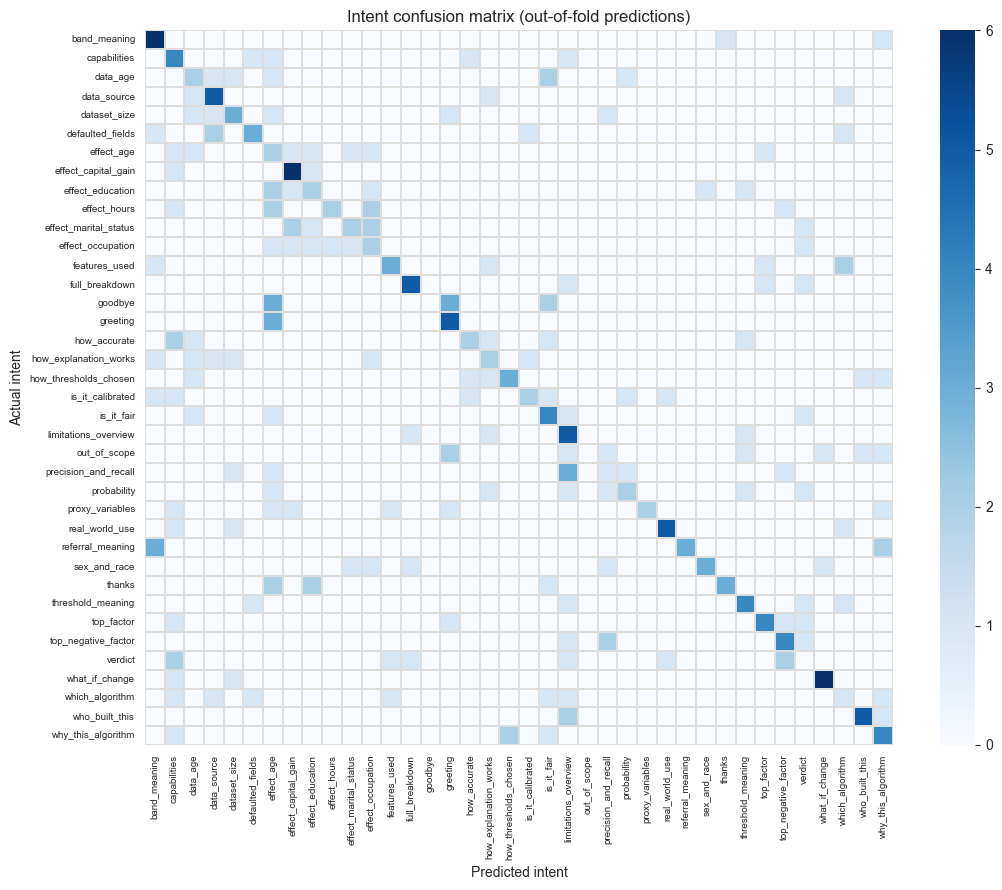

Most frequent confusions
               actual            predicted  count
              goodbye             greeting      3
              goodbye           effect_age      3
     referral_meaning         band_meaning      3
 precision_and_recall limitations_overview      3
             greeting           effect_age      3
     defaulted_fields          data_source      2
             data_age           is_it_fair      2
     effect_education           effect_age      2
effect_marital_status    effect_occupation      2
              verdict  top_negative_factor      2


In [34]:
matrix = confusion_matrix(y_intent, oof_pred, labels=classes)

fig_cm, ax_cm = plt.subplots(figsize=(11, 9))
sns.heatmap(matrix, cmap='Blues', cbar=True, ax=ax_cm,
            xticklabels=classes, yticklabels=classes,
            linewidths=0.3, linecolor='#DDDDDD')
ax_cm.set_xlabel('Predicted intent')
ax_cm.set_ylabel('Actual intent')
ax_cm.set_title('Intent confusion matrix (out-of-fold predictions)')
plt.setp(ax_cm.get_xticklabels(), rotation=90, fontsize=7)
plt.setp(ax_cm.get_yticklabels(), rotation=0, fontsize=7)
fig_cm.tight_layout()
save_figure('intent_confusion_matrix', fig_cm)
plt.show()

confusions = []
for i, actual in enumerate(classes):
    for j, predicted in enumerate(classes):
        if i != j and matrix[i, j] > 0:
            confusions.append({'actual': actual, 'predicted': predicted,
                               'count': int(matrix[i, j])})

confusion_pairs = pd.DataFrame(confusions).sort_values('count', ascending=False)
print("Most frequent confusions")
print(confusion_pairs.head(10).to_string(index=False))

### 7.2 The figure that determines whether the interface works

The interface offers questions as buttons rather than a text box, so every message the classifier
receives at run time is one of the thirty eight display strings. Those strings were held out of
training, so this is a test of generalisation, but it is a test over exactly the inputs the
application will actually see.

In [35]:
artefact = joblib.load(MODELS / 'intent_model.joblib')
deployed = artefact['model']

displays = [i['display'] for i in intents]
expected = np.array([i['tag'] for i in intents])

display_proba = deployed.predict_proba(
    vectorise_many(displays, artefact['vocabulary'], binary=artefact['binary']))
display_pred = np.array(artefact['tags'])[display_proba.argmax(axis=1)]
display_conf = display_proba.max(axis=1)
display_correct = display_pred == expected

print(f"Display strings resolving to their own intent: "
      f"{display_correct.sum()}/{len(displays)} ({display_correct.mean():.1%})")
print(f"Confidence on buttons: lowest {display_conf.min():.4f}, "
      f"median {np.median(display_conf):.4f}, highest {display_conf.max():.4f}")

for d, p, e, c in zip(displays, display_pred, expected, display_conf):
    if p != e:
        print(f"  FAILS  '{d}' reached {p} instead of {e} at {c:.3f}")

print("\nFive lowest-confidence buttons")
lowest = pd.DataFrame({'display': displays, 'intent': expected,
                       'confidence': display_conf}).sort_values('confidence')
print(lowest.head(5).to_string(index=False, float_format=lambda v: f"{v:.4f}"))

Display strings resolving to their own intent: 38/38 (100.0%)
Confidence on buttons: lowest 0.1161, median 0.8303, highest 0.9958

Five lowest-confidence buttons
                                 display                intent  confidence
                                 Goodbye               goodbye      0.1161
                                   Hello              greeting      0.1180
                               Thank you                thanks      0.2791
                          Something else          out_of_scope      0.3904
Where did the band boundaries come from? how_thresholds_chosen      0.4140


### 7.3 The confidence threshold

Naive Bayes always names a winner, however unlike the input is to anything it was trained on. A
confidence threshold converts the weakest of those guesses into an honest fallback response.

The threshold has an upper bound set by the interface itself: it must sit below the lowest
confidence observed on any legitimate button, or the application will refuse to answer a question
the user selected from its own menu. Within that ceiling, a higher threshold catches more wrong
answers.

In [36]:
candidates = np.round(np.arange(0.00, 0.51, 0.02), 2)

rows = []
for threshold in candidates:
    suppressed_wrong = ((~oof_correct) & (oof_conf < threshold)).sum()
    suppressed_right = (oof_correct & (oof_conf < threshold)).sum()
    rows.append({
        'threshold': threshold,
        'wrong_answers_caught': int(suppressed_wrong),
        'share_of_wrong_caught': suppressed_wrong / max((~oof_correct).sum(), 1),
        'correct_answers_lost': int(suppressed_right),
        'buttons_suppressed': int((display_conf < threshold).sum()),
    })

sweep = pd.DataFrame(rows)
print(sweep[sweep['threshold'].isin([0.02, 0.06, 0.10, 0.12, 0.20, 0.30, 0.40])]
      .to_string(index=False, float_format=lambda v: f"{v:.3f}"))

 threshold  wrong_answers_caught  share_of_wrong_caught  correct_answers_lost  buttons_suppressed
     0.020                     0                  0.000                     0                   0
     0.060                    14                  0.074                     0                   0
     0.100                    57                  0.303                     2                   0
     0.120                    77                  0.410                     9                   2
     0.200                   132                  0.702                    30                   2
     0.300                   160                  0.851                    52                   3
     0.400                   175                  0.931                    66                   4


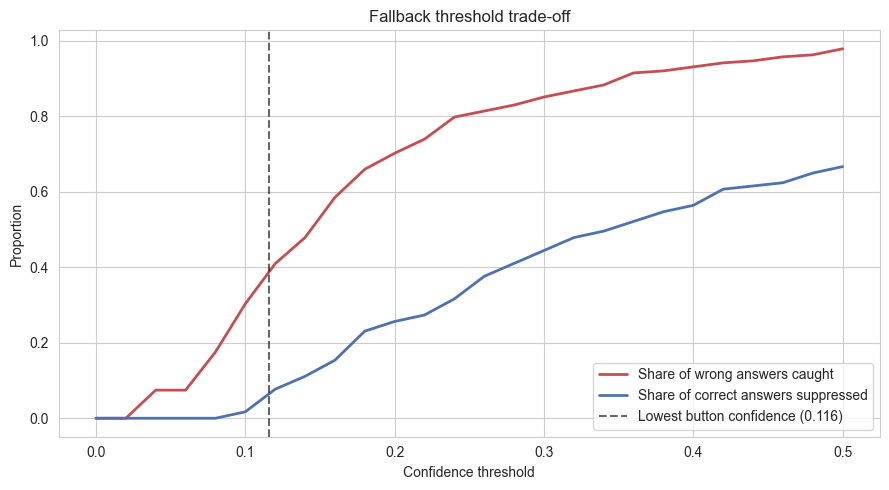

In [37]:
fig_th, ax_th = plt.subplots(figsize=(9, 5))
ax_th.plot(sweep['threshold'], sweep['share_of_wrong_caught'],
           color='#C44E52', lw=2, label='Share of wrong answers caught')
ax_th.plot(sweep['threshold'], sweep['correct_answers_lost'] / oof_correct.sum(),
           color='#4C72B0', lw=2, label='Share of correct answers suppressed')
ax_th.axvline(display_conf.min(), ls='--', color='k', alpha=0.6,
              label=f'Lowest button confidence ({display_conf.min():.3f})')
ax_th.set_xlabel('Confidence threshold')
ax_th.set_ylabel('Proportion')
ax_th.set_title('Fallback threshold trade-off')
ax_th.legend()
fig_th.tight_layout()
save_figure('intent_threshold_tradeoff', fig_th)
plt.show()

In [38]:
CONFIDENCE_THRESHOLD = 0.10

chosen = sweep[sweep['threshold'] == CONFIDENCE_THRESHOLD].iloc[0]
print(f"Chosen threshold: {CONFIDENCE_THRESHOLD}")
print(f"  buttons suppressed        {int(chosen['buttons_suppressed'])} of {len(displays)}")
print(f"  wrong answers caught      {int(chosen['wrong_answers_caught'])} "
      f"of {int((~oof_correct).sum())} ({chosen['share_of_wrong_caught']:.1%})")
print(f"  correct answers lost      {int(chosen['correct_answers_lost'])} "
      f"of {int(oof_correct.sum())}")

print()
for probe in ['purple monkey dishwasher', 'what is the capital of france',
              'asdkjfh qwerty', 'which algorithm is this']:
    p = deployed.predict_proba(
        vectorise_many([probe], artefact['vocabulary'], binary=artefact['binary']))[0]
    verdict = 'fallback' if p.max() < CONFIDENCE_THRESHOLD else artefact['tags'][p.argmax()]
    print(f"  '{probe[:34]:<34}' {p.max():.3f} -> {verdict}")

Chosen threshold: 0.1
  buttons suppressed        0 of 38
  wrong answers caught      57 of 188 (30.3%)
  correct answers lost      2 of 117

  'purple monkey dishwasher          ' 0.030 -> fallback
  'what is the capital of france     ' 0.106 -> limitations_overview
  'asdkjfh qwerty                    ' 0.030 -> fallback
  'which algorithm is this           ' 0.596 -> which_algorithm


In [39]:
intent_metrics = {
    'evaluated_at': pd.Timestamp.now('UTC').isoformat(timespec='seconds'),
    'intents': len(intents),
    'patterns': len(patterns),
    'vocabulary_size': len(vocabulary),
    'alpha': INTENT_ALPHA,
    'binary_presence': INTENT_BINARY,
    'cross_validation_folds': 4,
    'out_of_fold_accuracy': float(oof_correct.mean()),
    'macro_f1': float(report['macro avg']['f1-score']),
    'weighted_f1': float(report['weighted avg']['f1-score']),
    'display_accuracy': float(display_correct.mean()),
    'display_confidence': {
        'lowest': float(display_conf.min()),
        'median': float(np.median(display_conf)),
        'highest': float(display_conf.max()),
    },
    'confidence_threshold': float(CONFIDENCE_THRESHOLD),
    'threshold_effect': {
        'buttons_suppressed': int(chosen['buttons_suppressed']),
        'wrong_answers_caught': int(chosen['wrong_answers_caught']),
        'wrong_answers_total': int((~oof_correct).sum()),
        'correct_answers_lost': int(chosen['correct_answers_lost']),
    },
    'per_intent': per_intent.to_dict(orient='records'),
    'top_confusions': confusion_pairs.head(10).to_dict(orient='records'),
}

with open(MODELS / 'intent_metrics.json', 'w') as handle:
    json.dump(intent_metrics, handle, indent=2)

print(f"Written to {MODELS / 'intent_metrics.json'}")

Written to C:\Users\Ausbeth\Documents\Important Docs\Southampton Solent\MSc Applied AI & Data Science\COM727-Chatbot-Assessment\models\intent_metrics.json
